In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

import os
data_path = '/content/drive/MyDrive/f1-telemetry-ml'
labeled_path = f'{data_path}/labeled'

print(f"Labeled data path: {labeled_path}")
print(f"Contents: {os.listdir(labeled_path)}")

Mounted at /content/drive
Labeled data path: /content/drive/MyDrive/f1-telemetry-ml/labeled
Contents: ['labels_2024_Silverstone_R.parquet', 'labels_2024_Jeddah_R.parquet', 'labels_2024_Monaco_R.parquet', 'labels_2024_Belgium_R.parquet', 'labels_2024_Bahrain_R.parquet', 'labels_2024_Singapore_R.parquet', 'labels_2024_Austin_R.parquet', 'labels_2024_Suzuka_R.parquet', 'labels_2024_Austria_R.parquet', 'labels_combined.parquet', 'labels_2024_Monza_R.parquet', 'test_zero_shot.parquet', 'train_data.parquet', 'test_in_dist_data.parquet', 'val_data.parquet']


In [7]:

# 1. Load combined globally normalized race labels
labels = pd.read_parquet(f'{labeled_path}/labels_combined.parquet')

# Basic shape of the dataset
print(f"Total labeled corner-instances: {labels.shape[0]}")
print(f"Races included ({labels['race'].nunique()} total): {labels['race'].unique()}")
print(f"Drivers included ({labels['driver'].nunique()} total): {labels['driver'].unique()}")
print("\nCorners per race:")
print(labels.groupby('race')['corner_number'].nunique())

Total labeled corner-instances: 146321
Races included (10 total): ['Monza' 'Bahrain' 'Belgium' 'Austin' 'Suzuka' 'Singapore' 'Silverstone'
 'Monaco' 'Jeddah' 'Austria']
Drivers included (23 total): ['ALB' 'ALO' 'BOT' 'COL' 'GAS' 'HAM' 'HUL' 'LEC' 'MAG' 'NOR' 'OCO' 'PER'
 'PIA' 'RIC' 'RUS' 'SAI' 'STR' 'TSU' 'VER' 'ZHO' 'SAR' 'LAW' 'BEA']

Corners per race:
race
Austin         20
Austria        10
Bahrain        15
Belgium        19
Jeddah         27
Monaco         19
Monza          11
Silverstone    18
Singapore      19
Suzuka         18
Name: corner_number, dtype: int64


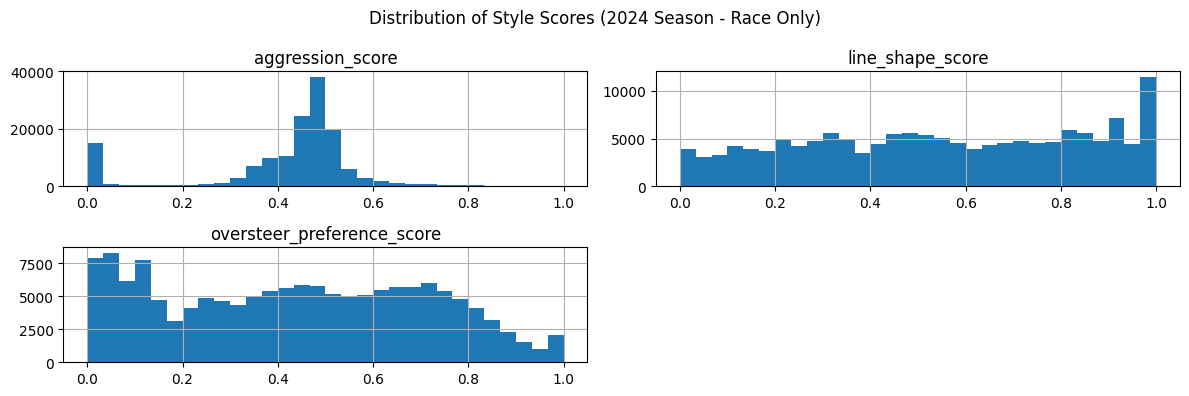

In [8]:

# 2. Distribution of target scores
labels[['aggression_score', 'line_shape_score', 'oversteer_preference_score']].hist(figsize=(12, 4), bins=30)
plt.suptitle('Distribution of Style Scores (2024 Season - Race Only)')
plt.tight_layout()
plt.show()

In [9]:
# 3. Summary statistics
print("\n=== Target Score Statistics ===")
print(labels[['aggression_score', 'line_shape_score', 'oversteer_preference_score']].describe())


=== Target Score Statistics ===
       aggression_score  line_shape_score  oversteer_preference_score
count     146321.000000     146321.000000               146321.000000
mean           0.417105          0.549877                    0.435169
std            0.165265          0.293243                    0.272341
min            0.000000          0.000000                    0.000000
25%            0.392227          0.305062                    0.185501
50%            0.466305          0.549540                    0.439444
75%            0.498051          0.817148                    0.663702
max            1.000000          1.000000                    1.000000


In [10]:
# 4. Driver style comparison (Turn 1 benchmark)
turn_1 = labels[labels['corner_number'] == 1]

# Define target metric columns
style_cols = ['aggression_score', 'line_shape_score', 'oversteer_preference_score']

# Group by driver, calculate mean across all style metrics, and sort by Aggression
turn_1_driver_styles = (
    turn_1.groupby('driver')[style_cols]
    .mean()
    .sort_values(by='aggression_score', ascending=False)
)

print("\n=== Top Drivers by Turn 1 Style Profile ===")
print(turn_1_driver_styles.head(20).round(4))



=== Top Drivers by Turn 1 Style Profile ===
        aggression_score  line_shape_score  oversteer_preference_score
driver                                                                
GAS               0.4886            0.2559                      0.7271
LAW               0.4856            0.1467                      0.7970
COL               0.4826            0.2320                      0.7620
BOT               0.4786            0.2888                      0.6926
PER               0.4777            0.2966                      0.6754
RUS               0.4770            0.2859                      0.7615
BEA               0.4763            0.2158                      0.8852
PIA               0.4746            0.3202                      0.6869
HAM               0.4744            0.3344                      0.6909
HUL               0.4736            0.2982                      0.7328
ZHO               0.4727            0.2684                      0.7119
TSU               0.4712        

In [11]:
# 5. Session type verification (Should be exclusively 'R')
print("\n=== Session Type Breakdown ===")
print(labels['session_type'].value_counts())


=== Session Type Breakdown ===
session_type
R    146321
Name: count, dtype: int64


In [12]:
# 6. Train / Val / Test / Zero-Shot Track Split
output_dir = labeled_path

# Define track partitioning
TRAIN_TRACKS = ["Monza", "Monaco", "Silverstone", "Suzuka", "Austin", "Bahrain"]
VAL_TRACKS = ["Singapore", "Austria"]
TEST_IN_DIST_TRACKS = ["Monza", "Silverstone"]
HOLDOUT_TRACKS = ["Belgium", "Jeddah"]
# 1. Zero-Shot Holdout Set (Unseen Tracks)
zero_shot_df = labels[labels['race'].isin(HOLDOUT_TRACKS)].copy()

# 2. Validation Set (Dedicated Validation Tracks)
val_df = labels[labels['race'].isin(VAL_TRACKS)].copy()

# 3. Pure Training-Only Tracks (Monaco, Suzuka, Austin, Bahrain)
pure_train_tracks = list(set(TRAIN_TRACKS) - set(TEST_IN_DIST_TRACKS))
pure_train_df = labels[labels['race'].isin(pure_train_tracks)].copy()

# 4. Handle In-Distribution Overlapping Tracks (Monza & Silverstone)
# Split by lap number to prevent corner leakage between Train and In-Dist Test
in_dist_df = labels[labels['race'].isin(TEST_IN_DIST_TRACKS)].copy()

train_overlap_list = []
test_in_dist_list = []

np.random.seed(42)  # For reproducible lap splits
for (race, driver), group in in_dist_df.groupby(['race', 'driver']):
    unique_laps = group['lap_number'].unique()
    np.random.shuffle(unique_laps)

    # 80% laps for training, 20% laps for in-distribution testing
    split_idx = int(len(unique_laps) * 0.8)
    train_laps = unique_laps[:split_idx]
    test_laps = unique_laps[split_idx:]

    train_overlap_list.append(group[group['lap_number'].isin(train_laps)])
    test_in_dist_list.append(group[group['lap_number'].isin(test_laps)])

train_overlap_df = pd.concat(train_overlap_list, ignore_index=True)
test_in_dist_df = pd.concat(test_in_dist_list, ignore_index=True)

# Combine pure training tracks with the training lap slice of overlap tracks
train_df = pd.concat([pure_train_df, train_overlap_df], ignore_index=True)

# ---------------------------------------------------------
# Save Processed Parquet Splits
# ---------------------------------------------------------
train_df.to_parquet(f'{output_dir}/train_data.parquet', index=False)
val_df.to_parquet(f'{output_dir}/val_data.parquet', index=False)
test_in_dist_df.to_parquet(f'{output_dir}/test_in_dist_data.parquet', index=False)
zero_shot_df.to_parquet(f'{output_dir}/test_zero_shot.parquet', index=False)

# ---------------------------------------------------------
# Summary Verification Printout
# ---------------------------------------------------------
print("=== Data Split Summary ===")
print(f"Train Set           ({train_df['race'].nunique()} tracks): {train_df.shape[0]} rows -> {train_df['race'].unique().tolist()}")
print(f"Val Set             ({val_df['race'].nunique()} tracks): {val_df.shape[0]} rows -> {val_df['race'].unique().tolist()}")
print(f"In-Dist Test Set    ({test_in_dist_df['race'].nunique()} tracks): {test_in_dist_df.shape[0]} rows -> {test_in_dist_df['race'].unique().tolist()}")
print(f"Zero-Shot Test Set  ({zero_shot_df['race'].nunique()} tracks): {zero_shot_df.shape[0]} rows -> {zero_shot_df['race'].unique().tolist()}")

=== Data Split Summary ===
Train Set           (6 tracks): 73818 rows -> ['Bahrain', 'Austin', 'Suzuka', 'Monaco', 'Monza', 'Silverstone']
Val Set             (2 tracks): 32350 rows -> ['Singapore', 'Austria']
In-Dist Test Set    (2 tracks): 4152 rows -> ['Monza', 'Silverstone']
Zero-Shot Test Set  (2 tracks): 36001 rows -> ['Belgium', 'Jeddah']
